In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("lahore_flats_feature_engineered.csv")

In [3]:
df.columns

Index(['name', 'marla', 'area_sqft', 'floor_number', 'total_floors',
       'built_year', 'address', 'description', 'floor', 'floors_in_building',
       'bedrooms', 'bathrooms', 'kitchens', 'servant_quarters', 'store_rooms',
       'price', 'society', 'luxury_score', 'drawing_room', 'dining_room',
       'lounge_or_sitting_room', 'laundry_room', 'study_room', 'prayer_room',
       'powder_room', 'gym', 'steam_room', 'other_rooms'],
      dtype='object')

In [4]:
df = df.drop(columns=["name", "description"])

In [5]:
df = df.drop(columns=["address"])

In [6]:
df[['floor_number','total_floors','floor','floors_in_building']]

,floor_number,total_floors,floor,floors_in_building
0,8.0,11.0,8.0,11.0
1,NaN,13.0,NaN,13.0
2,6.0,11.0,6.0,11.0
3,NaN,8.0,NaN,8.0
4,1.0,9.0,1.0,9.0
...,...,...,...,...
2494,2.0,7.0,2.0,7.0
2495,1.0,NaN,1.0,NaN
2496,NaN,7.0,NaN,7.0
2497,NaN,NaN,NaN,NaN


In [7]:
df = df.drop(columns=["floor", "floors_in_building"])


In [8]:
df.columns

Index(['marla', 'area_sqft', 'floor_number', 'total_floors', 'built_year',
       'bedrooms', 'bathrooms', 'kitchens', 'servant_quarters', 'store_rooms',
       'price', 'society', 'luxury_score', 'drawing_room', 'dining_room',
       'lounge_or_sitting_room', 'laundry_room', 'study_room', 'prayer_room',
       'powder_room', 'gym', 'steam_room', 'other_rooms'],
      dtype='object')

In [9]:
df["area_sqft"] = pd.to_numeric(df["area_sqft"], errors="coerce")
df["price_per_sqft"] = df["price"] / df["area_sqft"]


In [10]:
df.columns

Index(['marla', 'area_sqft', 'floor_number', 'total_floors', 'built_year',
       'bedrooms', 'bathrooms', 'kitchens', 'servant_quarters', 'store_rooms',
       'price', 'society', 'luxury_score', 'drawing_room', 'dining_room',
       'lounge_or_sitting_room', 'laundry_room', 'study_room', 'prayer_room',
       'powder_room', 'gym', 'steam_room', 'other_rooms', 'price_per_sqft'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2499 entries, 0 to 2498
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   marla                   2499 non-null   float64
 1   area_sqft               2499 non-null   float64
 2   floor_number            1095 non-null   float64
 3   total_floors            1352 non-null   float64
 4   built_year              1800 non-null   float64
 5   bedrooms                2145 non-null   float64
 6   bathrooms               2146 non-null   float64
 7   kitchens                2074 non-null   float64
 8   servant_quarters        1657 non-null   float64
 9   store_rooms             1723 non-null   float64
 10  price                   2499 non-null   int64  
 11  society                 2499 non-null   object 
 12  luxury_score            2499 non-null   int64  
 13  drawing_room            2499 non-null   int64  
 14  dining_room             2499 non-null   

In [12]:
df.duplicated().sum()

np.int64(36)

In [13]:
df = df.drop_duplicates()

In [14]:
df.shape

(2463, 24)

In [15]:
df.head()

,marla,area_sqft,floor_number,total_floors,built_year,bedrooms,bathrooms,kitchens,servant_quarters,store_rooms,...,dining_room,lounge_or_sitting_room,laundry_room,study_room,prayer_room,powder_room,gym,steam_room,other_rooms,price_per_sqft
0,1.3,353.925,8.0,11.0,NaN,1.0,1.0,1.0,1.0,1.0,...,1,1,1,0,0,0,0,0,0,15257.469803
1,1.8,490.050,NaN,13.0,NaN,1.0,1.0,1.0,NaN,NaN,...,0,1,0,0,0,0,0,0,0,4401.591674
2,2.2,598.950,6.0,11.0,NaN,1.0,1.0,1.0,NaN,NaN,...,0,0,0,0,0,0,0,0,0,13356.707572
3,2.2,598.950,NaN,8.0,2023.0,NaN,1.0,1.0,1.0,1.0,...,1,1,1,1,1,1,1,1,1,3339.176893
4,2.2,598.950,1.0,9.0,2023.0,1.0,1.0,1.0,1.0,1.0,...,1,1,1,1,1,1,1,1,1,4173.971116


## Univarient Analysis
- Col dist
- outliers
- missing val

## society                 

In [16]:
df['society'].value_counts().shape

(87,)

In [17]:
df['society'].value_counts()

society
Askari 11         499
Gulberg           293
Askari 10         288
DHA Defence       250
Raiwind Road      232
                 ... 
Sant Nagar          1
Super Town          1
Saadi Park          1
EME Society         1
Cavalry Ground      1
Name: count, Length: 87, dtype: int64

In [18]:
df[df["society"] != "Askari 11"]["society"].value_counts(normalize=True).cumsum().head(75)


society
Gulberg                                0.149185
Askari 10                              0.295825
DHA Defence                            0.423116
Raiwind Road                           0.541242
Gulberg 3                              0.624745
                                         ...   
Mustafa Town                           0.992363
Abdul Sattar Edhi Road                 0.992872
Bahria Education & Medical City        0.993381
Shabbir Town - Executive Apartments    0.993890
Davis Road                             0.994399
Name: proportion, Length: 75, dtype: float64

In [19]:
society_counts = df["society"].value_counts()

frequency_bins = {
    "Very High (>100)": (society_counts > 100).sum(),
    "High (50-100)": ((society_counts >= 50) & (society_counts <= 100)).sum(),
    "Average (10-49)": ((society_counts >= 10) & (society_counts < 50)).sum(),
    "Low (2-9)": ((society_counts > 1) & (society_counts < 10)).sum(),
    "Very Low (1)": (society_counts == 1).sum()
}

frequency_bins


{'Very High (>100)': np.int64(6),
 'High (50-100)': np.int64(4),
 'Average (10-49)': np.int64(12),
 'Low (2-9)': np.int64(39),
 'Very Low (1)': np.int64(26)}

<Axes: xlabel='society'>

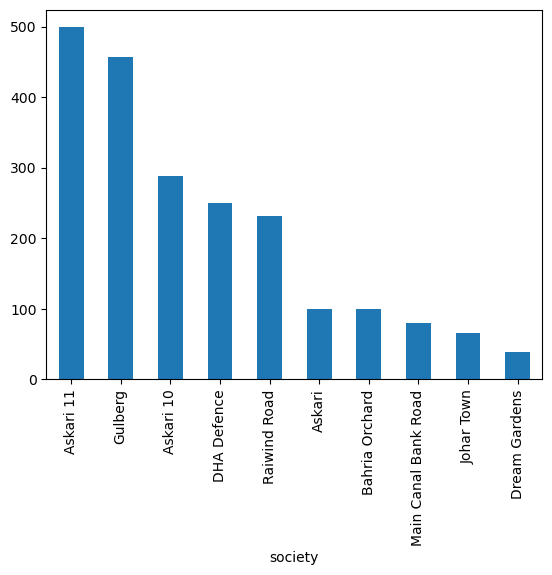

In [23]:
df["society"].value_counts().head(10).plot(kind='bar')

In [21]:
df['society'].isnull().sum()

np.int64(0)

In [27]:
dict(df['society'].value_counts())

{'Askari 11': np.int64(499),
 'Gulberg': np.int64(458),
 'Askari 10': np.int64(288),
 'DHA Defence': np.int64(250),
 'Raiwind Road': np.int64(232),
 'Bahria Orchard': np.int64(100),
 'Askari': np.int64(100),
 'Main Canal Bank Road': np.int64(80),
 'Johar Town': np.int64(66),
 'Dream Gardens': np.int64(39),
 'Shanghai Road': np.int64(32),
 'Bahria Town': np.int64(26),
 'Khayaban-e-Amin': np.int64(17),
 'New Lahore City': np.int64(14),
 'Jubilee Town': np.int64(14),
 'Ferozepur Road': np.int64(13),
 'Sukh Chayn Gardens': np.int64(13),
 'Land Breeze Housing Society': np.int64(12),
 'Allama Iqbal Town': np.int64(11),
 'Paragon City': np.int64(11),
 'Garden Town': np.int64(10),
 'Izmir Town': np.int64(9),
 'Model Town': np.int64(9),
 'Wapda Town': np.int64(9),
 'Lake City': np.int64(8),
 'Multan Road': np.int64(8),
 'PAF Falcon Complex': np.int64(7),
 'Nespak Housing Scheme': np.int64(5),
 'Shadman 2': np.int64(5),
 'Jail Road': np.int64(5),
 'Pine Avenue': np.int64(5),
 'PIA Housing Scheme

In [ ]:
df["society"] = df["society"].replace(r"^Gulberg 3(\s+\d+)?$", "Gulberg", regex=True)

In [ ]:
df["society"] = df["society"].replace(r"^Main Market(\s+\d+)?$", "Gulberg", regex=True)

### Observability
- 87 socities/area
- {'Very High (>100)': np.int64(5),
- 'High (50-100)': np.int64(4),
- 'Average (10-49)': np.int64(12),
- 'Low (2-9)': np.int64(38),
- 'Very Low (1)': np.int64(24)}
- no missing val

## Price

In [28]:
df['price'].isnull().sum()

np.int64(0)

In [31]:
df['price'].value_counts()

price
35000000    55
45000000    44
27500000    37
32500000    33
44000000    31
            ..
5412000      1
7250000      1
2790000      1
2772000      1
5652000      1
Name: count, Length: 505, dtype: int64

In [30]:
df['price'].describe()

count    2.463000e+03
mean     2.427430e+07
std      1.686481e+07
min      1.800000e+06
25%      9.000000e+06
50%      2.430000e+07
75%      3.550000e+07
max      1.800000e+08
Name: price, dtype: float64

In [32]:
df["price_crore"] = df["price"] / 1e7
# df["price_lakh"] = df["price"] / 1e5


In [36]:
df['price'].min()

1800000

In [37]:
df['price_crore'].min()

0.18

In [38]:
df["price_crore"] = df["price"] / 1e7
p=df['price']
df = df.drop(columns=["price"]).rename(columns={"price_crore": "price"})

In [44]:
p.iloc[90]

np.int64(25000000)

In [45]:
df['price'].iloc[90]

np.float64(2.5)

In [47]:
df['price'].describe()

count    2463.000000
mean        2.427430
std         1.686481
min         0.180000
25%         0.900000
50%         2.430000
75%         3.550000
max        18.000000
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Count'>

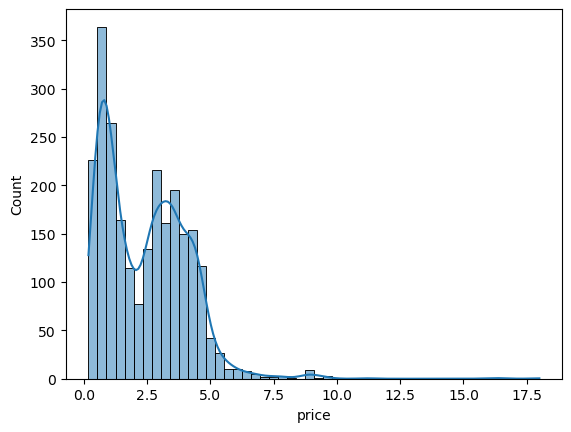

In [50]:
sns.histplot(df["price"], kde=True, bins=50)

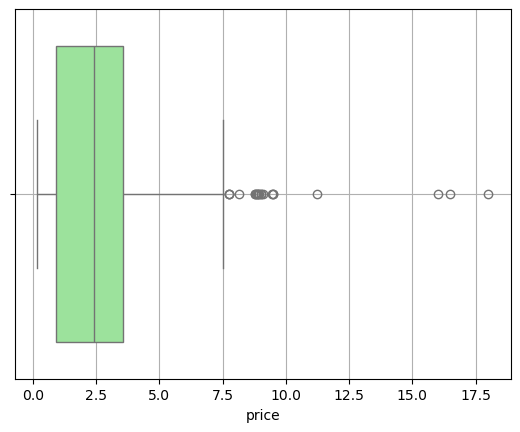

In [51]:
sns.boxplot(x=df["price"], color="lightgreen")
plt.grid()


`Descriptive Statistics` **(df['price'].describe())**
- Count: 2,463 non-missing price entries  
- Mean: ~2.43 crore  
- Median (50%): 2.43 crore  
- Std Dev: ~1.69  
- Range: 0.18 to 18.00 crore  
- IQR: 0.90 to 3.55 crore  

**Visualizations**
- Histogram: Strong right-skew; most prices are below ~5 crore, with a long tail.  
- Box Plot: Several high-end outliers, with values extending up to ~18 crore.  

**Missing Values**
- Missing count: 0


In [ ]:
# Skewness and Kurtosis
skewness = df["price"].skew() # how much your data skwed 
kurtosis = df["price"].kurt() # how much haviness in tail
print(skewness, kurtosis)


1.3768192864287199 6.720583576378985


- **Skewness:** ~1.38 → positively skewed (right‑tailed). Most properties are lower‑priced with a few high‑priced outliers.  
- **Kurtosis:** ~6.72 → heavier tails than normal, indicating more extreme values/outliers.  


In [53]:
# Quantile Analysis
quantiles = df["price"].quantile([0.01, 0.05, 0.95, 0.99])
quantiles


0.01    0.300
0.05    0.450
0.95    4.850
0.99    6.938
Name: price, dtype: float64

**Quantile Analysis**
- **1% Quantile:** 1% of properties are priced below **0.30 crore**.  
- **5% Quantile:** 5% of properties are priced below **0.45 crore**.  
- **95% Quantile:** 95% of properties are priced below **4.85 crore**.  
- **99% Quantile:** 99% of properties are priced below **6.94 crore**, so only 1% are higher.  


In [54]:
# Identify potential outliers using IQR method
Q1 = df["price"].describe()["25%"]
Q3 = df["price"].describe()["75%"]
IQR = Q3 - Q1
IQR


np.float64(2.65)

In [55]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(lower_bound, upper_bound)


-3.0749999999999997 7.5249999999999995


In [ ]:
outliers = df[(df["price"] < lower_bound) | (df["price"] > upper_bound)]
outliers.shape

(21, 24)

In [57]:
outliers["price"].describe()


count    21.000000
mean     10.028095
std       2.961237
min       7.740000
25%       8.780000
50%       8.950000
75%       9.500000
max      18.000000
Name: price, dtype: float64

**Outliers Analysis (using IQR method):**
- Based on the IQR method, there are **21** properties considered outliers.  
- These outliers have an **average price of ~10.03 crores**.  
- The **range** for these outliers is **7.74 to 18.00 crores**.  


<Axes: xlabel='price'>

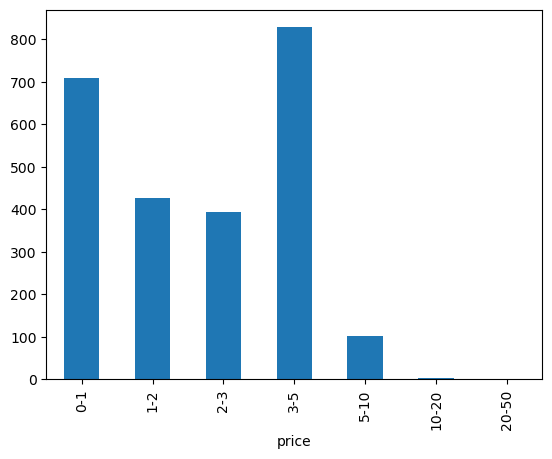

In [58]:
# price binning
bins = [0, 1, 2, 3, 5, 10, 20, 50]
bin_labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20-50"]
pd.cut(df["price"], bins=bins, labels=bin_labels, right=False).value_counts().sort_index().plot(kind="bar")


- Most listings fall in the **0–1** and **3–5 crore** bins, with moderate counts in **1–2** and **2–3**.  
- There’s a sharp drop after **5 crore**; very few listings appear above **10 crore**.  


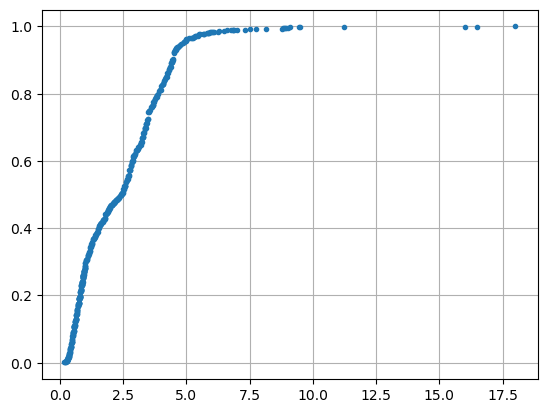

In [60]:
# ecdf plot
ecdf = df["price"].value_counts().sort_index().cumsum() / len(df["price"])
plt.plot(ecdf.index, ecdf, marker=".", linestyle="none")
plt.grid()


In [61]:
df.shape

(2463, 24)

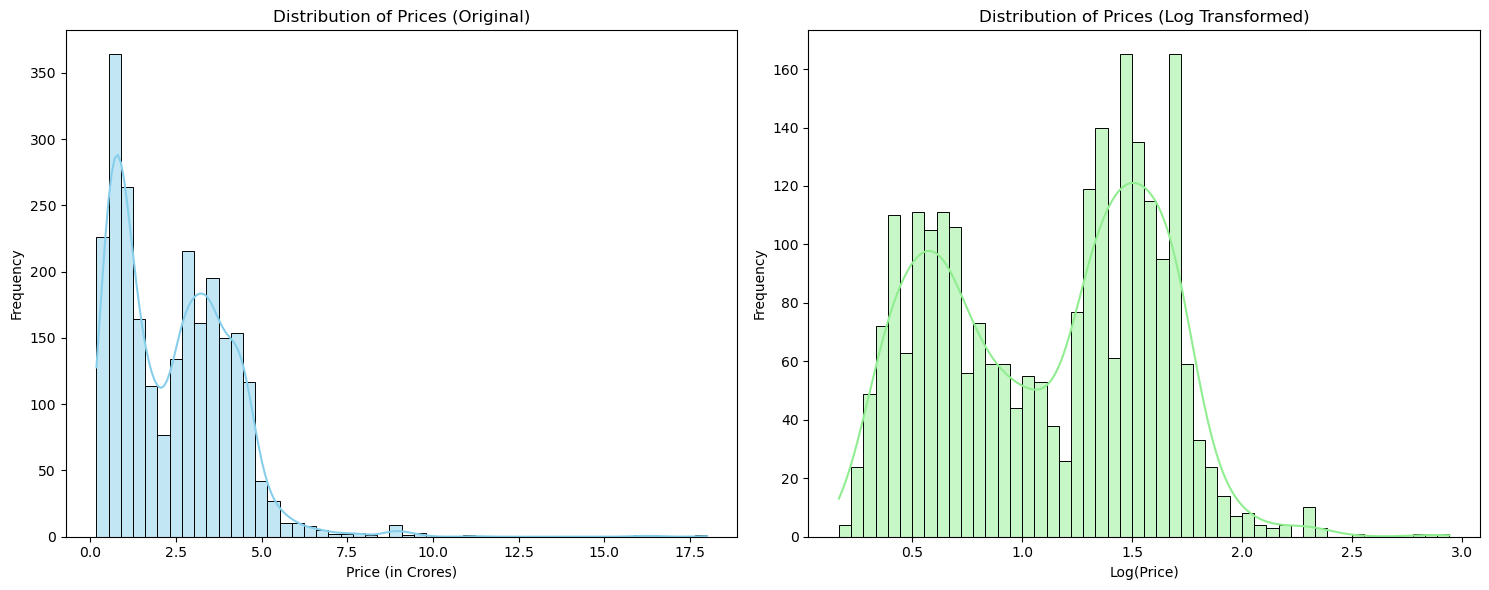

In [62]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.histplot(df["price"], kde=True, bins=50, color="skyblue")
plt.title("Distribution of Prices (Original)")
plt.xlabel("Price (in Crores)")
plt.ylabel("Frequency")

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df["price"]), kde=True, bins=50, color="lightgreen")
plt.title("Distribution of Prices (Log Transformed)")
plt.xlabel("Log(Price)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


`np.log1p(x)` computes `ln(1 + x)`, which is more numerically stable for values near 0.  
It’s useful for transforming the price column because it safely handles zero values.  
To reverse it, use `np.expm1(y)` which computes `e^y - 1`.


In [63]:
# Skewness & kurtosis (log-transformed)
skewness = np.log1p(df["price"]).skew()
kurtosis = np.log1p(df["price"]).kurt()
print(skewness, kurtosis)


-0.03703527124728626 -1.0438833009018773


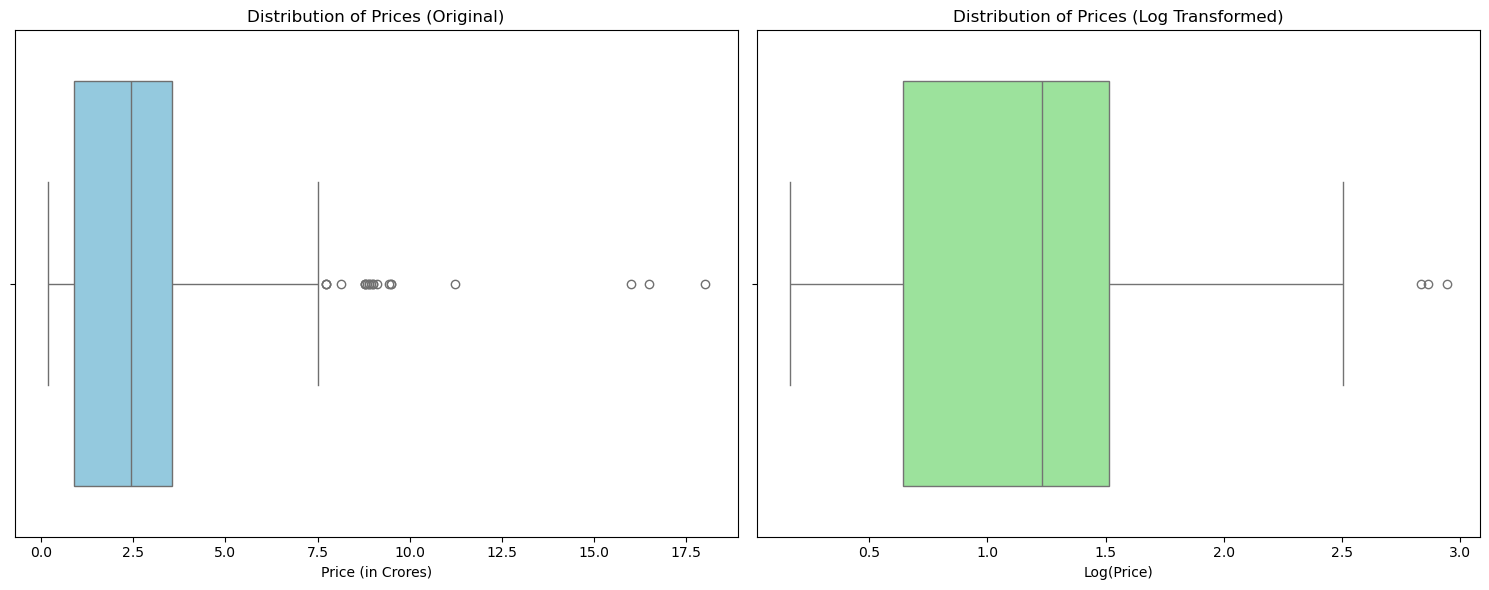

In [64]:
plt.figure(figsize=(15, 6))

# Box plot without log transformation
plt.subplot(1, 2, 1)
sns.boxplot(x=df["price"], color="skyblue")
plt.title("Distribution of Prices (Original)")
plt.xlabel("Price (in Crores)")

# Box plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(x=np.log1p(df["price"]), color="lightgreen")
plt.title("Distribution of Prices (Log Transformed)")
plt.xlabel("Log(Price)")

plt.tight_layout()
plt.show()


## price per sqft

## Pandas profiling

## Multivarient analysis